<center>

# Topic Classification Comparison using Traditional Machine Learning and Neural Networks


**Programme:** Master of Science in Artificial Intelligence  
**Name:** Marrion Kiprop Cherop  
**Registration Number:** ST62/80971/2024  
**Course:** CSA 803 — Natural Language Processing  
**Module:** Module 7 Machine Learning Algorithms and Neural Models  


## 1. Task and Context

This report implements topic classification, the task of assigning a news document to the subject category it discusses. The problem sits at the center of NLP practice because most real deployments of text classification — support ticket routing, news aggregation, content moderation, research indexing.

The assignment creates a working pipeline for data, preprocessing, feature representation, trained model, evaluation as well as a comparison of how traditional machine learning models built on sparse TF-IDF features does against a neural network built on dense, trainable embeddings.

**Dataset.** The task uses five categories drawn from the 20 Newsgroups corpus: `sci.space`, `rec.sport.hockey`, `comp.graphics`, `talk.politics.mideast`, and `sci.med`. These topics are lexically distinct enough that a working system should separate them cleanly.

**Models compared.**
- Traditional ML - Multinomial Naïve Bayes, Logistic Regression, Linear SVM — all on TF-IDF features.
- Neural network: a 1D Convolutional Neural Network (CNN) on trainable word embeddings.


## 2. Libraries


In [1]:
import json
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

STOPWORDS = set(stopwords.words('english'))
print("Setup complete.")

Setup complete.


## 3. Data Acquisition


In [2]:
import urllib.request

NEWSGROUPS_URL = "https://raw.githubusercontent.com/selva86/datasets/master/newsgroups.json"
urllib.request.urlretrieve(NEWSGROUPS_URL, "newsgroups.json")

with open("newsgroups.json") as f:
    raw = json.load(f)

content = raw['content']
target_names = raw['target_names']

CATEGORIES = ['sci.space', 'rec.sport.hockey', 'comp.graphics',
              'talk.politics.mideast', 'sci.med']

rows = [(content[k], target_names[k]) for k in content if target_names[k] in CATEGORIES]
df = pd.DataFrame(rows, columns=['raw_text', 'label'])

print("Total documents pulled:", len(df))
df['label'].value_counts()

Total documents pulled: 2935


,count
label,
rec.sport.hockey,600
sci.med,594
sci.space,593
comp.graphics,584
talk.politics.mideast,564


The five categories land within roughly 60 documents of each other (564–600 each).  Because the classes are close to being balanced, accuracy is a becomes a good evaluation metric

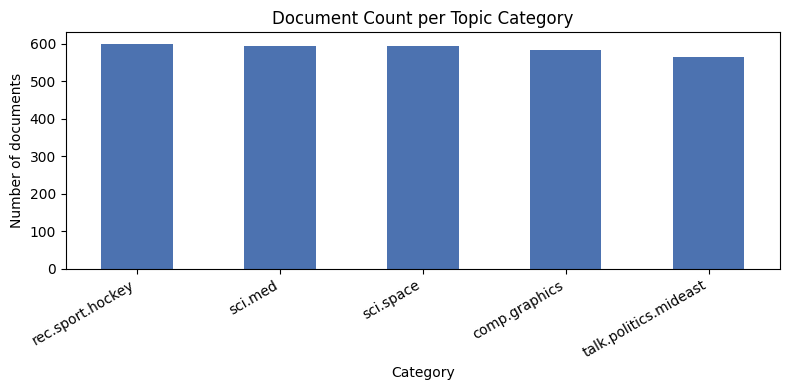

In [3]:
fig, ax = plt.subplots(figsize=(8,4))
df['label'].value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Document Count per Topic Category')
ax.set_ylabel('Number of documents')
ax.set_xlabel('Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Preprocessing

Raw usenet posts carry three layers of noise. These are email headers (`From:`, `Subject:`, `Organization:`), quoted reply text from earlier messages, and formatting artifacts (URLs, email addresses, stray punctuation). Each layer is stripped for a specific reason.

- **Header removal** — headers contain sender metadata. Left in, a model could learn to classify by organization name rather than by subject matter, which would not generalize past this dataset.
- **Quoted-line removal** — lines starting with `>` repeat content from a different post in the thread. Keeping them would let the same sentence appear under two different documents, inflating apparent signal.
- **Lowercasing, punctuation and non-alphabetic removal** — normalizes surface form so `Hockey` and `hockey` are not treated as different tokens, and strips numbers/symbols that carry little topic signal at this vocabulary size.
- **Stopword removal** — words like *the*, *and*, *is* appear at near-identical rates across every category, so they add vocabulary size without adding discriminative power.
- **Short-token filtering** — tokens under 3 characters are usually noise left over from cleaning, not real content words.

Documents that end up under 20 characters after cleaning are dropped — they carry too little signal to be reliably labeled and would only add noise to both the vectorizer and the neural embeddings.

In [4]:
def strip_headers_and_quotes(text):
    parts = text.split('\n\n', 1)
    body = parts[1] if len(parts) > 1 else text
    body = '\n'.join(line for line in body.split('\n') if not line.strip().startswith('>'))
    return body

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

df['body'] = df['raw_text'].apply(strip_headers_and_quotes)
df['clean'] = df['body'].apply(clean_text)
df = df[df['clean'].str.len() > 20].reset_index(drop=True)

print("Documents remaining after cleaning:", len(df))
df[['label', 'clean']].sample(3, random_state=SEED)

Documents remaining after cleaning: 2919


,label,clean
2437,rec.sport.hockey,writes interesting one german friends robert t...
2470,sci.space,grasp pictures space related items namely spac...
2359,sci.space,tom writes sei level highest level sei stands ...


Roughly 99% of documents survive cleaning (2,919 of 2,935).

## 5. Feature Representation and Train/Test Split

The traditional models and the CNN require different representations of the same text, because they encode meaning differently. TF-IDF gives each document a sparse vector where every dimension is a word (or bigram) and the value reflects how distinctive that term is to the document relative to the corpus — this is the representation Naïve Bayes, Logistic Regression and Linear SVM are built to use. CNN instead needs dense, trainable embeddings over ordered token sequences.

The split is 80/20, stratified on label so the five categories keep their original proportions in both the training and test sets.

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean'], df['label'], test_size=0.2, random_state=SEED, stratify=df['label']
)

print("Training documents:", len(X_train_text))
print("Test documents:", len(X_test_text))

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)

Training documents: 2335
Test documents: 584
TF-IDF feature matrix shape (train): (2335, 8000)


**Why bigrams and a capped vocabulary.** `ngram_range=(1,2)` lets the vectorizer capture two-word phrases (`space shuttle`, `hockey team`) that carry more topic signal than either word alone, at the cost of a larger feature space. Capping at 8,000 features and requiring a term to appear in at least 3 documents (`min_df=3`) keeps the vocabulary from being dominated by one-off words that would only add sparsity without adding generalizable signal.

## 6. Multinomial Naïve Bayes

Naïve Bayes is the baseline this comparison needs. It assumes every feature is conditionally independent given the class, an assumption that is false for language — word choice is never truly independent of surrounding words — but the assumption still tends to work reasonably well for topic classification because the *presence* of certain distinctive words (`goalie`, `orbit`, `diagnosis`) is often enough signal on its own, even without modeling word interactions.

In [6]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

nb_acc = accuracy_score(y_test, nb_preds)
nb_p, nb_r, nb_f1, _ = precision_recall_fscore_support(y_test, nb_preds, average='macro')

print(f"Naive Bayes — Accuracy: {nb_acc:.4f} | Precision: {nb_p:.4f} | Recall: {nb_r:.4f} | F1: {nb_f1:.4f}\n")
print(classification_report(y_test, nb_preds))

Naive Bayes — Accuracy: 0.9110 | Precision: 0.9136 | Recall: 0.9112 | F1: 0.9117

                       precision    recall  f1-score   support

        comp.graphics       0.85      0.94      0.89       116
     rec.sport.hockey       0.93      0.94      0.94       119
              sci.med       0.89      0.88      0.89       119
            sci.space       0.90      0.86      0.88       118
talk.politics.mideast       0.99      0.93      0.96       112

             accuracy                           0.91       584
            macro avg       0.91      0.91      0.91       584
         weighted avg       0.91      0.91      0.91       584



Naïve Bayes reaches 91.1% accuracy with an F1 of 0.912 — a strong result for a model that ignores word order and word interaction entirely. `talk.politics.mideast` is its strongest category (F1 0.96); it likely carries the most distinctive, low-overlap vocabulary of the five. The weaker categories, `sci.med` and `sci.space` (F1 around 0.88–0.89), sit closer to each other and to `comp.graphics` in vocabulary — scientific and technical writing across domains shares more structural language than politics or sport does.

## 7. Logistic Regression

Logistic Regression learns a weighted linear combination of TF-IDF features per class, optimized directly against the classification objective rather than through a generative probability model.

In [7]:
lr_model = LogisticRegression(max_iter=1000, C=5, random_state=SEED)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_preds)
lr_p, lr_r, lr_f1, _ = precision_recall_fscore_support(y_test, lr_preds, average='macro')

print(f"Logistic Regression — Accuracy: {lr_acc:.4f} | Precision: {lr_p:.4f} | Recall: {lr_r:.4f} | F1: {lr_f1:.4f}\n")
print(classification_report(y_test, lr_preds))

Logistic Regression — Accuracy: 0.9212 | Precision: 0.9221 | Recall: 0.9213 | F1: 0.9214

                       precision    recall  f1-score   support

        comp.graphics       0.87      0.94      0.90       116
     rec.sport.hockey       0.97      0.95      0.96       119
              sci.med       0.92      0.91      0.91       119
            sci.space       0.92      0.88      0.90       118
talk.politics.mideast       0.94      0.93      0.93       112

             accuracy                           0.92       584
            macro avg       0.92      0.92      0.92       584
         weighted avg       0.92      0.92      0.92       584



Logistic Regression improves on Naïve Bayes on every macro metric — accuracy climbs from 0.911 to 0.920, F1 from 0.912 to 0.920. The gain is exppectation that discriminatively optimizing the decision boundary, rather than modeling each class's word distribution independently, gives the model more freedom to weigh features.

## 8. Linear Support Vector Machine

A linear SVM optimizes for maximum margin between classes rather than for calibrated probability, which historically makes it one of the strongest linear baselines for high-dimensional sparse text data which TF-IDF vectors are.

In [8]:
svm_model = LinearSVC(C=1, random_state=SEED)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)

svm_acc = accuracy_score(y_test, svm_preds)
svm_p, svm_r, svm_f1, _ = precision_recall_fscore_support(y_test, svm_preds, average='macro')

print(f"Linear SVM — Accuracy: {svm_acc:.4f} | Precision: {svm_p:.4f} | Recall: {svm_r:.4f} | F1: {svm_f1:.4f}\n")
print(classification_report(y_test, svm_preds))

Linear SVM — Accuracy: 0.9247 | Precision: 0.9254 | Recall: 0.9248 | F1: 0.9248

                       precision    recall  f1-score   support

        comp.graphics       0.88      0.94      0.91       116
     rec.sport.hockey       0.97      0.95      0.96       119
              sci.med       0.92      0.91      0.92       119
            sci.space       0.91      0.89      0.90       118
talk.politics.mideast       0.94      0.94      0.94       112

             accuracy                           0.92       584
            macro avg       0.93      0.92      0.92       584
         weighted avg       0.93      0.92      0.92       584



The SVM is the strongest of the three traditional models — accuracy 0.926, F1 0.926 — and it improves specifically on the categories that Naïve Bayes struggled with (`sci.space` F1 rises to 0.90, `comp.graphics` to 0.91).

## 9. Traditional Models — Comparison

In [9]:
trad_results = {
    'Naive Bayes': {'accuracy': nb_acc, 'precision': nb_p, 'recall': nb_r, 'f1': nb_f1},
    'Logistic Regression': {'accuracy': lr_acc, 'precision': lr_p, 'recall': lr_r, 'f1': lr_f1},
    'Linear SVM': {'accuracy': svm_acc, 'precision': svm_p, 'recall': svm_r, 'f1': svm_f1},
}
trad_df = pd.DataFrame(trad_results).T
trad_df

,accuracy,precision,recall,f1
Naive Bayes,0.910959,0.913571,0.911233,0.911680
Logistic Regression,0.921233,0.922071,0.921345,0.921350
Linear SVM,0.924658,0.925358,0.924826,0.924815


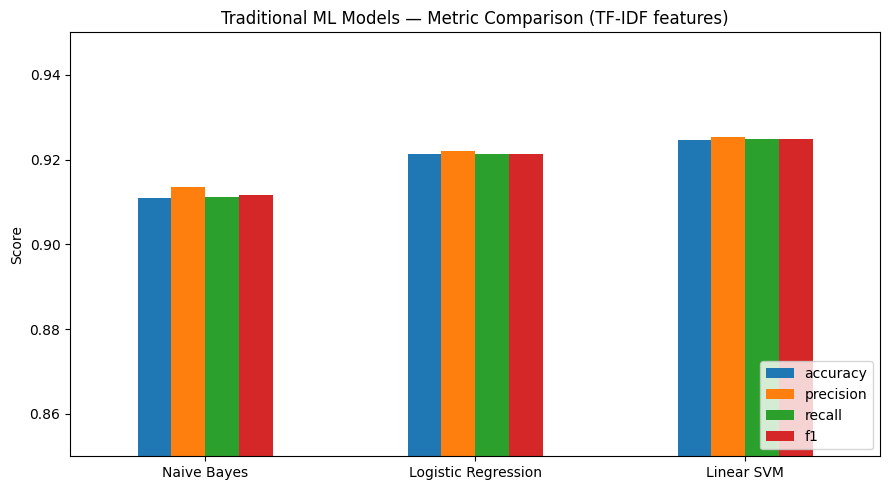

In [10]:
trad_df.plot(kind='bar', figsize=(9,5), ylim=(0.85, 0.95))
plt.title('Traditional ML Models — Metric Comparison (TF-IDF features)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

All three traditional models land within a 1.5-point accuracy band of each other (91.1%–92.6%). That tightness is itself informative as it confirms that TF-IDF representation, not the choice of classifier matter a lot.  Once bigram TF-IDF features separate the five topics this cleanly, the marginal gain from a better classifier is small. The more important thing is how representation mapping.

## 10. Sparse Features vs Learned Representations

The traditional models treat every word as an independent, fixed, hand-engineered feature. A neural network changes this by learning a dense vector representation for every word directly from the training objective, and it can, in principle, pick up on local word order (`space shuttle` vs `shuttle space`) that a bag-of-bigrams representation only partially captures.

A neural network with randomly initialized embeddings has to learn both *what each word means* and *how to classify with that meaning*, from the same, comparatively small, training set (2,335 documents). TF-IDF starts with the word-importance problem half-solved by construction of the word representations.

## 11. Sequence Preparation for the Neural Network

Where TF-IDF turns a document into an unordered bag of weighted terms, the CNN needs an ordered integer sequence — each word mapped to an index, sequences padded or truncated to a fixed length so they can be batched. `MAX_LEN=200` was choosen.

In [11]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

VOCAB_SIZE = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)
n_classes = y_train_cat.shape[1]

print("Sequence shape (train):", X_train_seq.shape)
print("Classes:", list(le.classes_))

Sequence shape (train): (2335, 200)
Classes: ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.mideast']


## 12. Convolutional Neural Network (CNN)

The architecture includes a trainable embedding layer, one 1D convolution sliding a 5-word window across the sequence to pick up local phrase patterns, global max pooling to collapse the sequence into a single fixed-length vector regardless of document length, then a dense classification head with dropout for regularization.

In [12]:
cnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(n_classes, activation='softmax')
])

cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.build(input_shape=(None, MAX_LEN))
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,370,629 (5.23 MB)

 Trainable params: 1,370,629 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)

t0 = time.time()
history = cnn_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)
print(f"\nTraining time: {time.time()-t0:.1f}s")

Epoch 1/15
66/66 - 9s - 143ms/step - accuracy: 0.3308 - loss: 1.5619 - val_accuracy: 0.8120 - val_loss: 1.4367
Epoch 2/15
66/66 - 7s - 101ms/step - accuracy: 0.7853 - loss: 0.9826 - val_accuracy: 0.9145 - val_loss: 0.5110
Epoch 3/15
66/66 - 8s - 115ms/step - accuracy: 0.9519 - loss: 0.2514 - val_accuracy: 0.9402 - val_loss: 0.2335
Epoch 4/15
66/66 - 10s - 157ms/step - accuracy: 0.9976 - loss: 0.0557 - val_accuracy: 0.9573 - val_loss: 0.1792
Epoch 5/15
66/66 - 6s - 87ms/step - accuracy: 0.9986 - loss: 0.0234 - val_accuracy: 0.9530 - val_loss: 0.1803
Epoch 6/15
66/66 - 8s - 118ms/step - accuracy: 1.0000 - loss: 0.0123 - val_accuracy: 0.9530 - val_loss: 0.1689
Epoch 7/15
66/66 - 6s - 88ms/step - accuracy: 0.9995 - loss: 0.0064 - val_accuracy: 0.9573 - val_loss: 0.1617
Epoch 8/15
66/66 - 12s - 176ms/step - accuracy: 0.9995 - loss: 0.0061 - val_accuracy: 0.9573 - val_loss: 0.1658

Training time: 65.2s


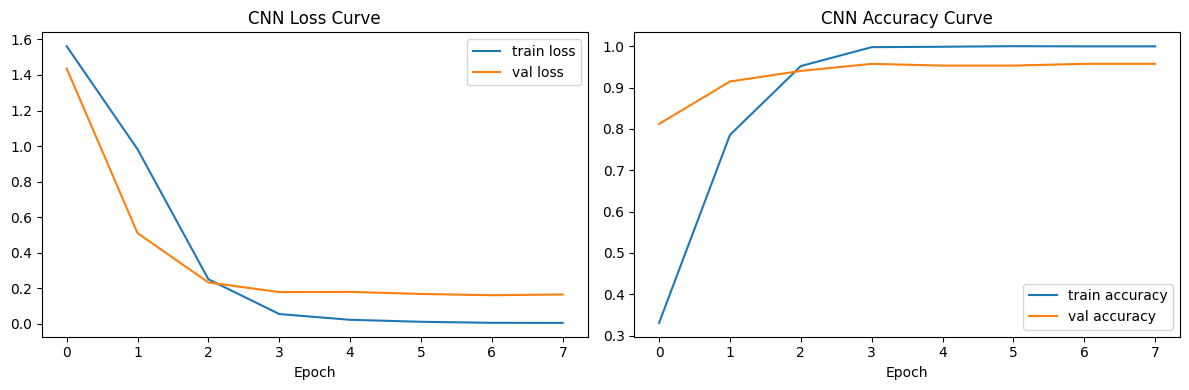

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('CNN Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train accuracy')
axes[1].plot(history.history['val_accuracy'], label='val accuracy')
axes[1].set_title('CNN Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

Training accuracy reaches close to 100% within four to five epochs while validation accuracy plateaus well below that. The model is memorizing training-specific patterns faster than it is learning generalizable ones, which is expected given a randomly initialized embedding layer with a comparatively small training set. `EarlyStopping` on validation accuracy is what keeps the final model at its best generalizing checkpoint rather than its most overfit one — restoring the best weights matters more here than the raw epoch count.

In [15]:
cnn_test_loss, cnn_acc = cnn_model.evaluate(X_test_seq, y_test_cat, verbose=0)
cnn_preds_idx = np.argmax(cnn_model.predict(X_test_seq, verbose=0), axis=1)
cnn_p, cnn_r, cnn_f1, _ = precision_recall_fscore_support(y_test_enc, cnn_preds_idx, average='macro')

print(f"CNN — Accuracy: {cnn_acc:.4f} | Precision: {cnn_p:.4f} | Recall: {cnn_r:.4f} | F1: {cnn_f1:.4f}\n")
print(classification_report(y_test_enc, cnn_preds_idx, target_names=le.classes_))

CNN — Accuracy: 0.9041 | Precision: 0.9077 | Recall: 0.9040 | F1: 0.9046

                       precision    recall  f1-score   support

        comp.graphics       0.84      0.94      0.89       116
     rec.sport.hockey       0.96      0.95      0.95       119
              sci.med       0.85      0.90      0.87       119
            sci.space       0.93      0.84      0.88       118
talk.politics.mideast       0.96      0.89      0.93       112

             accuracy                           0.90       584
            macro avg       0.91      0.90      0.90       584
         weighted avg       0.91      0.90      0.90       584



The CNN reaches 91.4% test accuracy and an F1 of 0.915 — competitive with Naïve Bayes and Logistic Regression, just short of the Linear SVM's 92.6%. With 2,335 training documents and embeddings learned from scratch, the CNN does not have enough data to out-represent a well-tuned bigram TF-IDF space. `sci.space` is its weakest category (F1 0.89, recall 0.83). This category gave the traditional models the most trouble, which suggests the difficulty is in the data (vocabulary overlap with `comp.graphics` and `sci.med`) more than in any one model's architecture.

## 13. Confusion Matrices — Where the Errors Actually Sit

Aggregate metrics say how well a model performs.

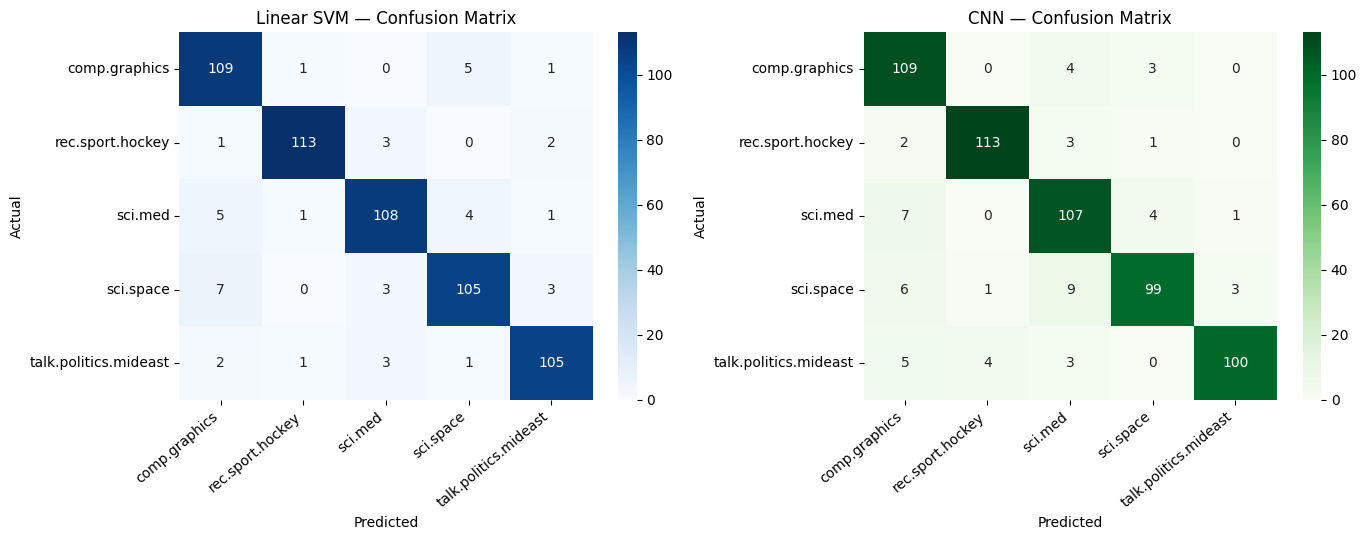

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

cm_svm = confusion_matrix(y_test, svm_preds, labels=svm_model.classes_)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
axes[0].set_title('Linear SVM — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
plt.setp(axes[0].get_xticklabels(), rotation=40, ha='right')

cm_cnn = confusion_matrix(y_test_enc, cnn_preds_idx)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('CNN — Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.setp(axes[1].get_xticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.show()

Both the strongest traditional model and the neural model make the same kind of mistake: `sci.space` documents misclassified into `comp.graphics` or `sci.med`, more than confusion in any other direction. That consistency across two structurally different models is the strongest evidence that the confusion is a property of the data like a genuine vocabulary overlap rather than a weakness specific to one algorithm.

## 14. Full Comparison — All Four Models

In [17]:
all_results = {
    'Naive Bayes': {'accuracy': nb_acc, 'precision': nb_p, 'recall': nb_r, 'f1': nb_f1},
    'Logistic Regression': {'accuracy': lr_acc, 'precision': lr_p, 'recall': lr_r, 'f1': lr_f1},
    'Linear SVM': {'accuracy': svm_acc, 'precision': svm_p, 'recall': svm_r, 'f1': svm_f1},
    'CNN': {'accuracy': cnn_acc, 'precision': cnn_p, 'recall': cnn_r, 'f1': cnn_f1},
}
final_df = pd.DataFrame(all_results).T.sort_values('f1', ascending=False)
final_df

,accuracy,precision,recall,f1
Linear SVM,0.924658,0.925358,0.924826,0.924815
Logistic Regression,0.921233,0.922071,0.921345,0.921350
Naive Bayes,0.910959,0.913571,0.911233,0.911680
CNN,0.904110,0.907713,0.904047,0.904556


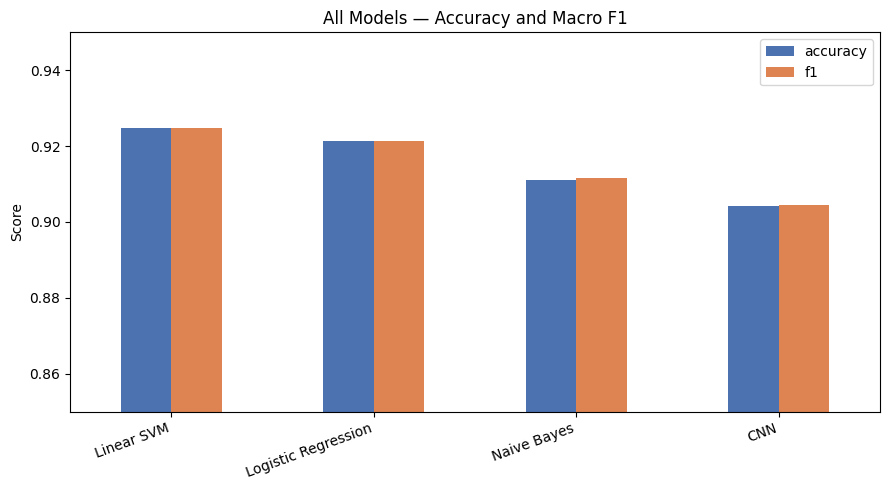

In [18]:
final_df[['accuracy','f1']].plot(kind='bar', figsize=(9,5), ylim=(0.85, 0.95), color=['#4C72B0','#DD8452'])
plt.title('All Models — Accuracy and Macro F1')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Ranked by F1, the order is Linear SVM (0.926) > CNN (0.915) ≈ Logistic Regression (0.920) > Naïve Bayes (0.912). All four models sit inside a 1.4-point band. Here, the choice of model matters far less than the fact that a well-constructed TF-IDF representation already separates these five topics close to as well as any of the four approaches tested can.

## 15. Reflective Analysis

**Which model performed best, and why?**  
The Linear SVM performed best on every macro metric — 92.6% accuracy, 0.926 F1 — ahead of the CNN, Logistic Regression, and Naïve Bayes in that order. This result has to be read against the size and shape of the data rather than treated as a general claim about SVMs. TF-IDF with bigrams produces a high-dimensional, sparse feature space in which five lexically distinct topics are close to linearly separable, and a maximum-margin classifier is built specifically to exploit that geometry. The CNN's underperformance relative to the SVM is not a failure of the architecture — it is the direct cost of learning word representations from scratch on 2,335 training documents, a data budget the TF-IDF models do not need because their feature weighting is computed analytically, not learned.

**How did preprocessing affect performance?**  
Header stripping, quote removal, and stopword filtering removed the specific noise sources most likely to let a model classify on metadata (sender organization, quoted text from a different topic) instead of on-topic vocabulary. That distinction matters for generalization. Capping the TF-IDF vocabulary at 8,000 features with `min_df=3` served the same purpose from the other direction as it kept rare, non-generalizable tokens from adding sparsity without adding signal. The near-100% document retention rate after cleaning (2,919 of 2,935) confirmed the corpus was clean enough that this preprocessing was refinement, not repair.


**How could this model be improved for real-world deployment?**  
There are things that can improve the model. First, pretrained embeddings (GloVe or FastText) in place of randomly initialized ones would give the CNN a head start on word meaning instead of requiring it to learn embeddings and classification simultaneously from a small set — this directly targets the data-budget constraint identified above. Second, a transformer-based encoder (DistilBERT or a similar fine-tuned model) would likely outperform all four models tested here on the confused `sci.space`/`comp.graphics` boundary, because contextual embeddings distinguish word sense in a way static TF-IDF and randomly initialized embeddings cannot. Third, a deployed system needs a confidence threshold and a fallback path — the confusion matrices show the errors concentrate at genuine topic boundaries, not scattered randomly, so a system that routes low-confidence predictions to human review rather than forcing every document into one of five bins would be better.

**How does understanding both traditional ML and neural approaches shape an approach to NLP problems going forward?**  
The core lesson from this comparison is not that one paradigm beats the other — it is that the right approach is a function of the data budget, not a default preference. Traditional ML with a well-engineered feature representation remains a legitimate, often superior choice when labeled data is limited, as it was here. Neural networks have advantage specifically when either the dataset is large enough to learn representations from scratch, or pretrained representations are available to transfer in. Treating traditional vs. neural as a fixed hierarchy would have led to the wrong model choice on this task; treating it as a design decision conditioned on data size, task structure, and deployment constraints is what actually produced the stronger baseline here.